## Import

In [1]:
import os
import time
import numpy as np
import scipy.linalg as linalg
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
#import preprocess


device = 'cuda:0'

%load_ext autoreload
%autoreload 2

## Experiment settings

In [2]:
mi_level = "mid"
mi_array = {'low':1, 'mid':3, 'high':7, 'very_high':9}
latent = False

mi = mi_array[mi_level]

## Data generation

image size torch.Size([10000, 16, 16]) torch.Size([10000, 16, 16])
data size torch.Size([10000, 256]) torch.Size([10000, 256])


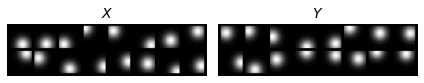

In [3]:
from image import image_dataset

X, Y = image_dataset.generate_gaussian_plot(mi=mi, n_samples=10000, device=device)

n, d = X.size()[0], 2*X.size()[1]

image_dataset.visualize_images(X, Y)

## Dimensionality reduction

In [7]:
from dr.Autoencoder import Autoencoder
from utils import utils_os


d_array = [4, 8, 16, 32, 64]
mse_array = {}


for latent in d_array:


    # [A]. Train autoencoder to compress data
    ae = Autoencoder(x_dim=d//2, y_dim=d//2, latent_size=latent, alpha=1, lam=0)

    ae.to(device)
    X, Y = X.to(device).float(), Y.to(device).float()
    ae.learn(X, Y)

    XX, YY = ae.encode(X, Y)
    XX, YY = XX.clone().detach(), YY.clone().detach()
    X_rec, Y_rec = ae.decode(XX, YY)
    
    # [B]. calculate reconstruction loss
    loss_x = ae.rec_loss(X_rec, X, normalize=True).item()
    loss_y = ae.rec_loss(Y_rec, Y, normalize=True).item()
    
    mse_array[latent] = (loss_x, loss_y)

    print('d=', latent, 'mse=', mse_array[latent])

finished: t= 0 loss= 0.22680535912513733 loss val= 0.226035013794899 best val loss= 0.226035013794899 best t= 0
finished: t= 101 loss= 0.00011319578334223479 loss val= 0.00010490450222278014 best val loss= 2.2688996978104115e-05 best t= 75
finished: t= 202 loss= 6.657917401753366e-05 loss val= 8.295241423184052e-05 best val loss= 9.354873327538371e-06 best t= 191
finished: t= 303 loss= 4.09632375522051e-05 loss val= 6.28878697170876e-05 best val loss= 5.855301878909813e-06 best t= 228
finished: t= 404 loss= 6.536511591548333e-06 loss val= 8.621525921626016e-06 best val loss= 4.290022843633778e-06 best t= 402
finished: t= 505 loss= 1.9581237211241387e-05 loss val= 1.5157032976276241e-05 best val loss= 3.0289670576166827e-06 best t= 442
finished: t= 606 loss= 3.3974924008361995e-05 loss val= 1.7659625882515684e-05 best val loss= 3.0289670576166827e-06 best t= 442


d= 4 mse= (1.5469013305846602e-05, 1.0995852790074423e-05)
finished: t= 0 loss= 0.22675681114196777 loss val= 0.226180121302

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


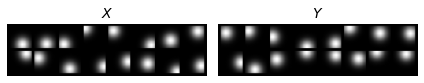

In [8]:
# from dr.Autoencoder import Autoencoder
# from utils import utils_os


# latent = 16

# # [A]. Train autoencoder to compress data
# ae = Autoencoder(x_dim=d//2, y_dim=d//2, latent_size=latent, alpha=1, lam=0)

# ae.to(device)
# X, Y = X.to(device).float(), Y.to(device).float()
# ae.learn(X, Y)


# # [B]. compress data and visualize
# XX, YY = ae.encode(X, Y)
# XX, YY = XX.clone().detach(), YY.clone().detach()
X_rec, Y_rec = ae.decode(XX, YY)
    
X_rec, Y_rec = X_rec.reshape(len(X_rec), 16, 16).detach().cpu(), Y_rec.reshape(len(Y_rec), 16, 16).detach().cpu()

image_dataset.visualize_images(X_rec, Y_rec)